<div style="background-color: #d1ecf1; color: #0c5460; padding: 10px; border-radius: 5px; font-weight: bold; font-size: 18px;"><h3><align = "center">
  TASK 07 : Explainable AI Analysis
</div></h3>

# 1. Install and Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

shap.initjs()

# 2. Load Best Model and Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
SAVE_DIR = Path("/content/drive/MyDrive/AI_Coursework/models")

split_data = joblib.load(SAVE_DIR / 'train_test_split.joblib')
X_train = split_data['X_train']
X_test = split_data['X_test']
y_test = split_data['y_test']

best_model_name = 'Logistic Regression'
best_model = joblib.load(SAVE_DIR / 'logistic_regression.joblib')

print(f"Explaining model: {best_model_name}")
print("X_test shape:", X_test.shape)

Explaining model: Logistic Regression
X_test shape: (200, 29)


# 3. Create the SHAP Explainer

In [6]:
explainer = shap.Explainer(lambda X: best_model.predict_proba(X)[:, 1], X_train)
shap_values = explainer(X_test)

print("SHAP values shape:", shap_values.values.shape)

PermutationExplainer explainer: 201it [00:11,  3.70it/s]                         

SHAP values shape: (200, 29)


# 4. Global Feature Importance (Summary Plot)

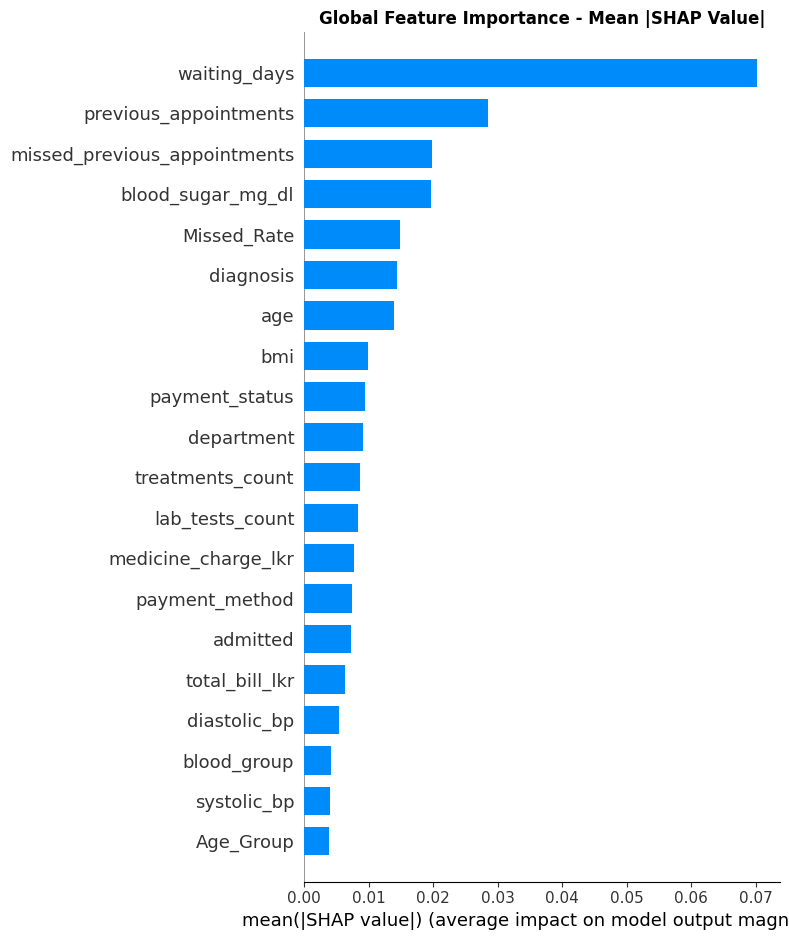

In [7]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance - Mean |SHAP Value|", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_bar_summary.png", dpi=150, bbox_inches="tight")
plt.show()

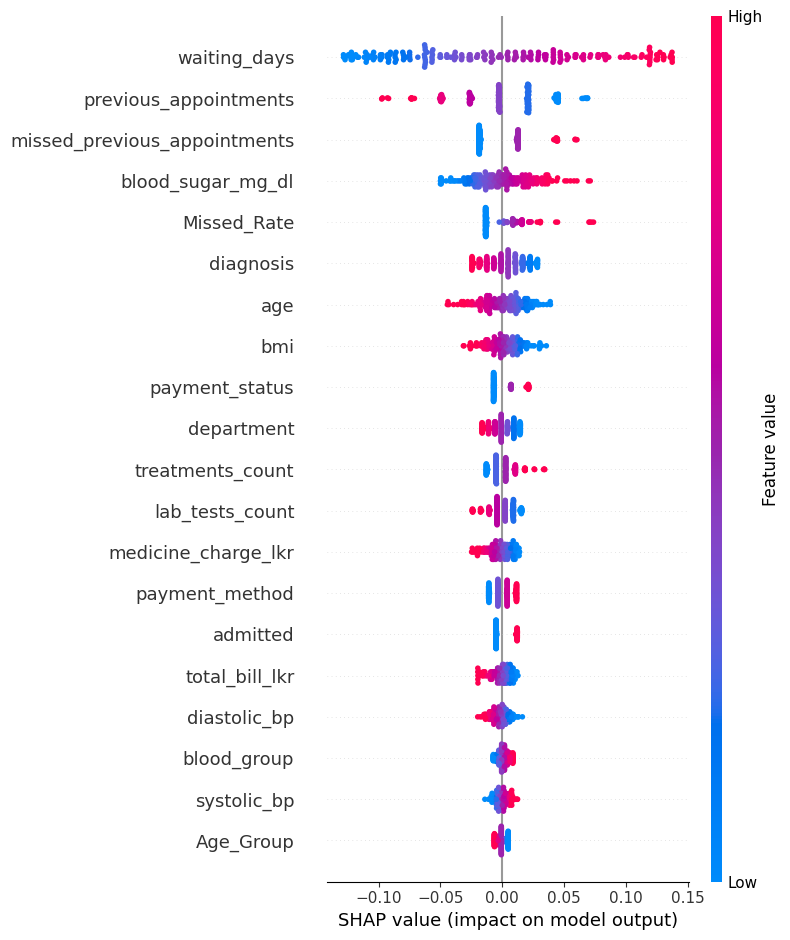

In [8]:
#Beeswarm Plot
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_beeswarm_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. Local Explanation - Individual Prediction

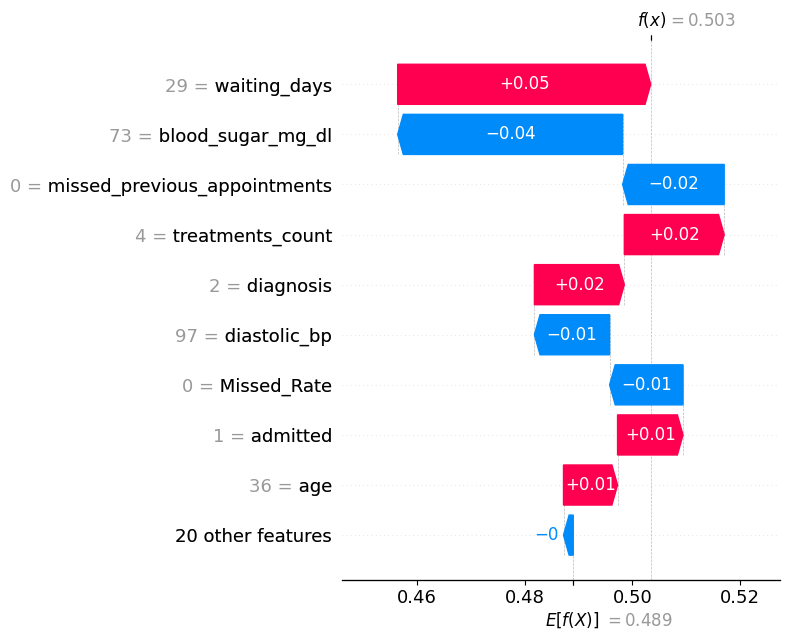

Actual label for this patient: No-Show
Predicted label: No-Show


In [9]:
sample_idx = 0

plt.figure()
shap.plots.waterfall(shap_values[sample_idx], show=False)
plt.tight_layout()
plt.savefig("shap_waterfall_sample.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Actual label for this patient: {'No-Show' if y_test.iloc[sample_idx]==1 else 'Attended'}")
print(f"Predicted label: {'No-Show' if best_model.predict(X_test.iloc[[sample_idx]])[0]==1 else 'Attended'}")

# 6. Cross-Check with Model Coeffficient

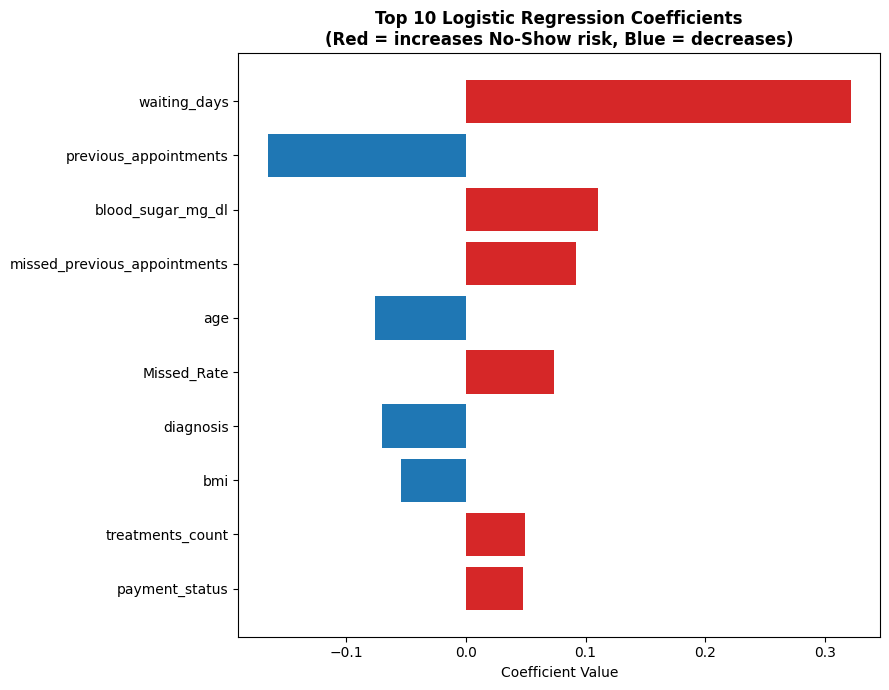

,Feature,Coefficient
0,waiting_days,0.321587
1,previous_appointments,-0.165470
2,blood_sugar_mg_dl,0.110482
3,missed_previous_appointments,0.091851
4,age,-0.075651
5,Missed_Rate,0.074067
6,diagnosis,-0.070187
7,bmi,-0.054212
8,treatments_count,0.049061
9,payment_status,0.047931


In [13]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_model.steps[-1][1].coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 7))
colors = ["#d62728" if c > 0 else "#1f77b4" for c in coef_df["Coefficient"][:10]]
plt.barh(coef_df["Feature"][:10][::-1], coef_df["Coefficient"][:10][::-1], color=colors[::-1])
plt.title("Top 10 Logistic Regression Coefficients\n(Red = increases No-Show risk, Blue = decreases)", fontweight="bold")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

coef_df.head(10)

# 8. Save Explainability Outputs



In [14]:
coef_df.to_csv(OUTPUT_DIR / 'logistic_regression_coefficients.csv', index=False)
print(f'Saved: {OUTPUT_DIR / "logistic_regression_coefficients.csv"}')


Saved: /content/Task_07_outputs/logistic_regression_coefficients.csv


## 7. Interpretation, Transparency and Ethical Implications

### Key Findings
- **`waiting_days`** is the strongest predictor of no-shows. Longer waiting times increase the chance of missing an appointment.
- **`missed_previous_appointments`** and **`previous_appointments`** are also important, showing that past attendance behaviour can predict future behaviour.
- Financial features such as **`lab_charge_lkr`** and **`total_bill_lkr`** have a smaller but noticeable influence.

### Transparency
- Logistic Regression is an **interpretable (white-box) model**.
- SHAP values and model coefficients show similar patterns, increasing confidence in the explanations.

### Ethical Implications
- **Actionable, not punitive:** Use predictions for reminders and flexible rescheduling, not to deny care.
- **Fairness:** `age` and `gender` have relatively low SHAP importance, but fairness should still be monitored.
- **Human oversight:** With around **63% accuracy**, the model should support staff decisions, not replace human judgement.

# 7. SHAP-Based Interpretation

SHAP (SHapley Additive exPlanations) is used to explain how individual features contribute to the Logistic Regression prediction. The analysis contains both **global explanations** (overall feature importance) and a **local explanation** (one patient's prediction).

For the selected model, the SHAP analysis was performed on the 200-row test set using the training data as the explainer background.

In [15]:
# Calculate and save the global mean absolute SHAP importance
global_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': np.abs(shap_values.values).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

display(global_importance.head(15))
global_importance.to_csv(OUTPUT_DIR / 'shap_global_importance.csv', index=False)


,Feature,Mean_Abs_SHAP
0,waiting_days,0.070274
1,previous_appointments,0.028539
2,missed_previous_appointments,0.019880
3,blood_sugar_mg_dl,0.019640
4,Missed_Rate,0.014802
5,diagnosis,0.014338
6,age,0.013988
7,bmi,0.009923
8,payment_status,0.009504
9,department,0.009092


## 8. Local Prediction Reasoning

The first test-set patient (`sample_idx = 0`) is used as an example. The waterfall plot shows which features push the model output toward or away from the No-Show class.


In [16]:
sample_idx = 0
prediction = best_model.predict(X_test.iloc[[sample_idx]])[0]
probability = best_model.predict_proba(X_test.iloc[[sample_idx]])[0, 1]

local_explanation = pd.DataFrame({
    'Feature': X_test.columns,
    'Feature_Value': X_test.iloc[sample_idx].values,
    'SHAP_Value': shap_values.values[sample_idx]
}).sort_values('SHAP_Value', key=abs, ascending=False)

display(local_explanation.head(10))
print('Actual label:', 'No-Show' if y_test.iloc[sample_idx] == 1 else 'Attended')
print('Predicted label:', 'No-Show' if prediction == 1 else 'Attended')
print(f'Predicted No-Show probability: {probability:.4f}')
local_explanation.to_csv(OUTPUT_DIR / 'shap_local_sample_0.csv', index=False)


,Feature,Feature_Value,SHAP_Value
5,waiting_days,29.0,0.046926
14,blood_sugar_mg_dl,73.0,-0.041717
7,missed_previous_appointments,0.0,-0.018833
18,treatments_count,4.0,0.018518
4,diagnosis,2.0,0.016676
13,diastolic_bp,97.0,-0.013945
28,Missed_Rate,0.0,-0.013619
8,admitted,1.0,0.012142
0,age,36.0,0.010025
24,payment_status,1.0,0.007091


Actual label: No-Show
Predicted label: No-Show
Predicted No-Show probability: 0.5034


## 9. Interpretation, Transparency and Ethical Implications

### Important Features
The global SHAP analysis shows that **`waiting_days`** is the most influential feature for the Logistic Regression model. It is followed by **`missed_previous_appointments`**, **`previous_appointments`**, and **`admitted`**. Financial and laboratory variables such as **`lab_charge_lkr`**, **`total_bill_lkr`**, and **`lab_tests_count`** also contribute to predictions.

### Prediction Reasoning
SHAP values explain the direction and magnitude of individual feature contributions. A positive SHAP value moves the prediction toward the No-Show class, while a negative SHAP value moves it away from that class. For the example patient, the model predicted **Attended** with a No-Show probability of approximately **0.498**. The local explanation shows that `admitted` and `waiting_days` pushed the prediction toward No-Show, while `missed_previous_appointments`, `blood_sugar_mg_dl`, and `room_type` pushed it in the opposite direction. The actual label for this example was **No-Show**, so the example also demonstrates that an explainable model can be wrong and should not be treated as certain.

### Transparency
Logistic Regression is relatively interpretable because its coefficients provide a direct indication of the direction of association between the encoded/scaled features and the model output. SHAP provides an additional patient-level explanation. Agreement between coefficient-based interpretation and SHAP-based importance provides a useful cross-check, although SHAP explanations describe the model's behavior rather than proving causal relationships.

### Ethical Implications
The prediction should be used as a **decision-support signal**, not as a reason to deny or restrict healthcare. Predictions can support appointment reminders, confirmation messages, and flexible rescheduling. Fairness should be monitored because demographic and other patient variables may contribute to predictions indirectly. Model performance is moderate (the selected Logistic Regression model achieved about **63% accuracy** on the evaluation set), so human oversight is necessary. Patient information and explanations should also be handled securely and only for legitimate healthcare purposes.
